In [1]:
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d tourist55/alzheimers-dataset-4-class-of-images

Dataset URL: https://www.kaggle.com/datasets/tourist55/alzheimers-dataset-4-class-of-images
License(s): ODbL-1.0
alzheimers-dataset-4-class-of-images.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
!ls

'Alzheimer_s Dataset'   alzheimers-dataset-4-class-of-images.zip   kaggle.json	 sample_data


In [5]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/alzheimers-dataset-4-class-of-images.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
#import the dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

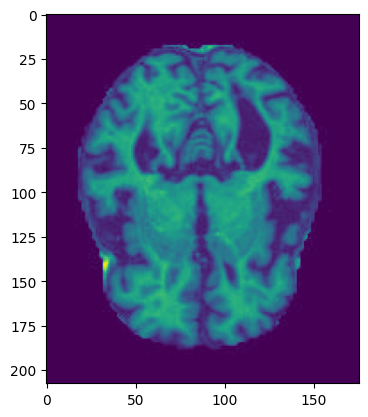

In [7]:
img = mpimg.imread('/content/Alzheimer_s Dataset/train/MildDemented/mildDem0.jpg')
imgplt = plt.imshow(img)
plt.show()

In [8]:
#Load training data and testing data

filename = os.listdir('/content/Alzheimer_s Dataset/train')
print(filename[:10])

filename1 = os.listdir('/content/Alzheimer_s Dataset/test')
print(filename1[:5])


['VeryMildDemented', 'MildDemented', 'ModerateDemented', 'NonDemented']
['VeryMildDemented', 'MildDemented', 'ModerateDemented', 'NonDemented']


In [9]:
mri_dict = {
      'NonDemented':0,
      'VeryMildDemented':1,
      'MildDemented':2,
      'ModerateDemented':3
  }

In [10]:
data=[]
mri_labels =[]

for file_name in filename:
  originial_path = os.path.join('/content/Alzheimer_s Dataset/train/', file_name)
  # print(originial_path)

  for img_file in os.listdir(originial_path):
    # print(originial_path + "/" +img_file)
    image = Image.open(originial_path + "/" +img_file)
    image = image.resize((200,200))
    image = image.convert('RGB')
    image = np.array(image)
    # print(image.shape)
    data.append(image)

    mri_labels.append(mri_dict[file_name])

for file_name in filename1:
  originial_path_te = os.path.join('/content/Alzheimer_s Dataset/test/', file_name)
  # print(originial_path)

  for img_file in os.listdir(originial_path_te):
    # print(originial_path + "/" +img_file)
    image = Image.open(originial_path_te + "/" +img_file)
    image = image.resize((200,200))
    image = image.convert('RGB')
    image = np.array(image)
    # print(image.shape)
    data.append(image)

    mri_labels.append(mri_dict[file_name])



In [11]:
X = np.array(data)
Y = np.array(mri_labels)

In [12]:
#Train and test

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [13]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [14]:
import tensorflow as tf
from tensorflow import keras

In [15]:
#import pretrained model vgg16
#We use Include_top=False to remove the classification layer that was trained on the ImageNet dataset and set the model as not trainable.
#Also, we used the preprocess_input function from VGG16 to normalize the input data.

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

base_model = VGG16(input_shape=(200,200,3), include_top=False)
base_model.trainable = False
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 200, 200, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 200, 200, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 100, 100, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 100, 100, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 100, 100, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 50, 50, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 50, 50, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 50, 50, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 50, 50, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 25, 25, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 25, 25, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 25, 25, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 25, 25, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 12, 12, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 6, 6, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
#Build cnn model
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')

])

In [17]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [ ]:
model.fit(X_train_scaled, Y_train, epochs=10)
model_loss, model_accuracy = model.evaluate(X_test_scaled, Y_test, verbose=2)
print(f"Loss: {model_loss}, Accuracy: {model_accuracy}")